<a href="https://colab.research.google.com/github/Tee-Sarun/DADS-6005-Real-Time-Analytics/blob/main/Time_Series_Analysis_(HW3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(144, 1)
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


<Axes: title={'center': 'Passengers Data'}, xlabel='Month'>

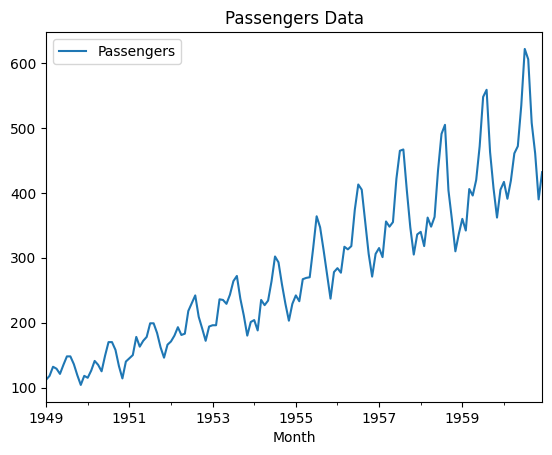

In [5]:
import pandas as pd
airline = pd.read_csv('/content/airline-passengers.csv',index_col='Month',
parse_dates=True)

# finding shape of the dataframe
print(airline.shape)

# having a look at the data
print(airline.head())

# plotting the original data
airline[['Passengers']].plot(title='Passengers Data')

In [6]:
display(airline.describe())

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


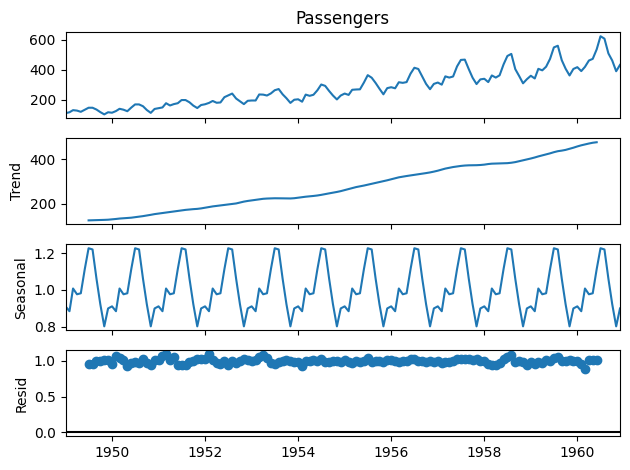

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# --- การแยกองค์ประกอบ Time Series (หน้า 8) ---
decompose_result = seasonal_decompose(airline['Passengers'], model='multiplicative')
decompose_result.plot()
plt.show()

In [9]:
# --- การตั้งค่าความถี่และตัวแปรพื้นฐาน (หน้า 9) ---
# ตั้งค่าความถี่เป็นรายเดือน (Monthly start)
airline.index.freq = 'MS'

# กำหนดค่า Alpha และ Time Period (m)
m = 12
alpha = 1 / (2 * m)

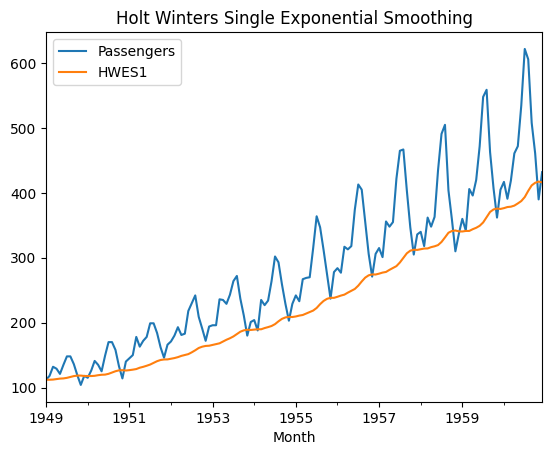

In [11]:
from statsmodels.tsa.api import SimpleExpSmoothing
import matplotlib.pyplot as plt

# --- 1. Single Exponential Smoothing (หน้า 10) ---
airline['HWES1'] = SimpleExpSmoothing(airline['Passengers']).fit(
    smoothing_level=alpha,
    optimized=False,
    use_brute=True
).fittedvalues

airline[['Passengers', 'HWES1']].plot(title='Holt Winters Single Exponential Smoothing')
plt.show()

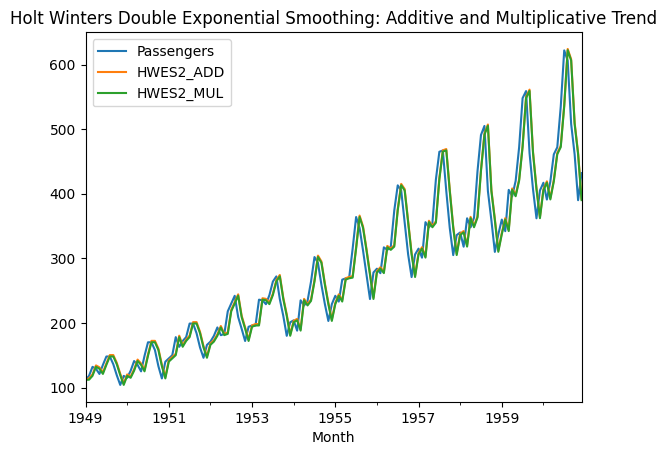

In [13]:
from statsmodels.tsa.api import ExponentialSmoothing
import matplotlib.pyplot as plt

# --- 2. Double Exponential Smoothing (หน้า 11) ---
# แบบ Additive Trend
airline['HWES2_ADD'] = ExponentialSmoothing(airline['Passengers'], trend='add').fit().fittedvalues
# แบบ Multiplicative Trend
alternative_column_name = 'Passengers' if 'Passengers' in airline.columns else 'Thousands of Passengers'
airline['HWES2_MUL'] = ExponentialSmoothing(airline['Passengers'], trend='mul').fit().fittedvalues

airline[['Passengers', 'HWES2_ADD', 'HWES2_MUL']].plot(
    title='Holt Winters Double Exponential Smoothing: Additive and Multiplicative Trend'
)
plt.show()

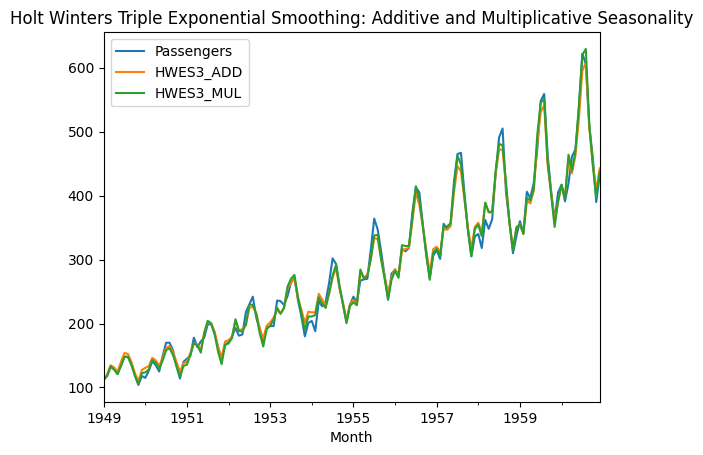

In [15]:
# --- 3. Triple Exponential Smoothing / Holt-Winters (หน้า 12) ---
# แบบ Additive Seasonality
airline['HWES3_ADD'] = ExponentialSmoothing(
    airline['Passengers'], trend='add', seasonal='add', seasonal_periods=12
).fit().fittedvalues

# แบบ Multiplicative Seasonality
airline['HWES3_MUL'] = ExponentialSmoothing(
    airline['Passengers'], trend='mul', seasonal='mul', seasonal_periods=12
).fit().fittedvalues

airline[['Passengers', 'HWES3_ADD', 'HWES3_MUL']].plot(
    title='Holt Winters Triple Exponential Smoothing: Additive and Multiplicative Seasonality'
)
plt.show()

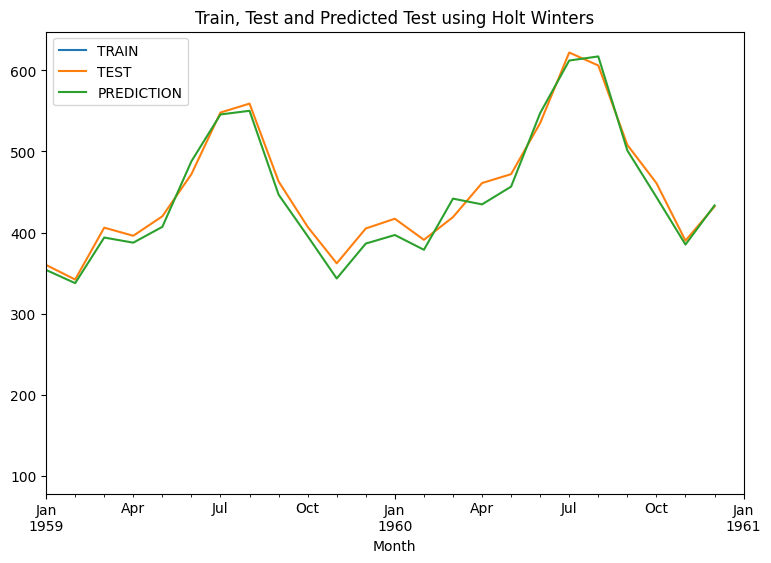

In [18]:
# --- การพยากรณ์ (Forecasting) (หน้า 13-14) ---
forecast_data = pd.read_csv('airline-passengers.csv', index_col='Month', parse_dates=True)
forecast_data.index.freq = 'MS'

# แบ่งข้อมูลเป็น Train (120 จุด) และ Test (24 จุด)
train_airline = forecast_data[:120]
test_airline = forecast_data[120:]

# สร้าง Model และพยากรณ์ 24 เดือนล่วงหน้า
fitted_model = ExponentialSmoothing(
    train_airline['Passengers'], trend='mul', seasonal='mul', seasonal_periods=12
).fit()
test_predictions = fitted_model.forecast(24)

# พล็อตกราฟเปรียบเทียบ Train, Test และ Prediction
train_airline['Passengers'].plot(legend=True, label='TRAIN')
test_airline['Passengers'].plot(legend=True, label='TEST', figsize=(9, 6))
test_predictions.plot(legend=True, label='PREDICTION', xlim=['1959-01-01', '1961-01-01'])
plt.title('Train, Test and Predicted Test using Holt Winters')
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- การวัดผล (Evaluation Metrics) (หน้า 15) ---
print(f'Mean Absolute Error = {mean_absolute_error(test_airline, test_predictions)}')
print(f'Mean Squared Error = {mean_squared_error(test_airline, test_predictions)}')

Mean Absolute Error = 12.380441443184715
Mean Squared Error = 192.6080692422504


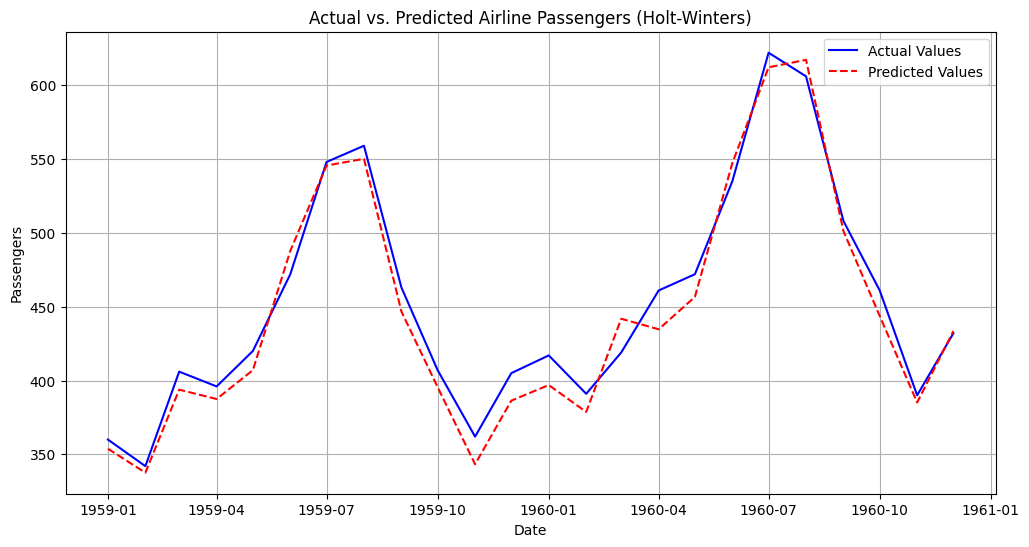

In [21]:
import matplotlib.pyplot as plt

# Ensure the indices are aligned for plotting
plt.figure(figsize=(12, 6))
plt.plot(test_airline.index, test_airline['Passengers'], label='Actual Values', color='blue')
plt.plot(test_predictions.index, test_predictions, label='Predicted Values', color='red', linestyle='--')
plt.title('Actual vs. Predicted Airline Passengers (Holt-Winters)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

### Comparing Error Metrics for Different Holt-Winters Combinations

Let's calculate the MAE and MSE for all four possible combinations of trend and seasonality to see which model performs best.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import ExponentialSmoothing

# Define the combinations of trend and seasonal components
combinations = [
    {'trend': 'mul', 'seasonal': 'mul'},
    {'trend': 'mul', 'seasonal': 'add'},
    {'trend': 'add', 'seasonal': 'mul'},
    {'trend': 'add', 'seasonal': 'add'}
]

results = []

for combo in combinations:
    current_trend = combo['trend']
    current_seasonal = combo['seasonal']

    print(f"\nEvaluating model with Trend: {current_trend}, Seasonal: {current_seasonal}")

    # Fit the model
    fitted_model = ExponentialSmoothing(
        train_airline['Passengers'],
        trend=current_trend,
        seasonal=current_seasonal,
        seasonal_periods=12
    ).fit()

    # Forecast
    test_predictions_combo = fitted_model.forecast(len(test_airline))

    # Calculate error metrics
    mae = mean_absolute_error(test_airline['Passengers'], test_predictions_combo)
    mse = mean_squared_error(test_airline['Passengers'], test_predictions_combo)

    results.append({
        'Trend': current_trend,
        'Seasonal': current_seasonal,
        'MAE': mae,
        'MSE': mse
    })

    print(f'Mean Absolute Error = {mae}')
    print(f'Mean Squared Error = {mse}')

# Optionally, display results in a DataFrame for better readability
import pandas as pd
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='MAE'))



Evaluating model with Trend: mul, Seasonal: mul
Mean Absolute Error = 12.380441443184715
Mean Squared Error = 192.6080692422504

Evaluating model with Trend: mul, Seasonal: add
Mean Absolute Error = 15.592583097468216
Mean Squared Error = 338.955096360826

Evaluating model with Trend: add, Seasonal: mul
Mean Absolute Error = 28.97719835139257
Mean Squared Error = 1055.5099097186187

Evaluating model with Trend: add, Seasonal: add
Mean Absolute Error = 31.07983843270132
Mean Squared Error = 1278.9475827409663


,Trend,Seasonal,MAE,MSE
0,mul,mul,12.380441,192.608069
1,mul,add,15.592583,338.955096
2,add,mul,28.977198,1055.509910
3,add,add,31.079838,1278.947583


### Comparison of Holt-Winters Model Combinations

```markdown


In [23]:
print(results_df.sort_values(by='MAE').to_markdown(index=False))


| Trend   | Seasonal   |     MAE |      MSE |
|:--------|:-----------|--------:|---------:|
| mul     | mul        | 12.3804 |  192.608 |
| mul     | add        | 15.5926 |  338.955 |
| add     | mul        | 28.9772 | 1055.51  |
| add     | add        | 31.0798 | 1278.95  |


# Project Report: Holt-Winters Time Series Analysis for Airline Passengers

## 1. Introduction
This report details the time series analysis and forecasting of monthly international airline passenger data using various Holt-Winters exponential smoothing models. The primary objective was to identify the underlying patterns in the data (trend and seasonality) and to build a predictive model to forecast future passenger numbers.

## 2. Data Overview
The dataset, `airline-passengers.csv`, contains 144 monthly records of international airline passengers from January 1949 to December 1960. Initial exploratory data analysis revealed a clear upward trend and a distinct seasonal pattern, suggesting that both trend and seasonality components would be crucial for accurate forecasting.

## 3. Methodology

### 3.1 Time Series Decomposition
Before applying forecasting models, the time series was decomposed into its trend, seasonal, and residual components using a multiplicative model. This confirmed the presence of a strong multiplicative trend and seasonality.

### 3.2 Holt-Winters Exponential Smoothing
We explored different variations of exponential smoothing models:
*   **Single Exponential Smoothing (SES):** Suitable for data with no trend or seasonality.
*   **Double Exponential Smoothing (DES):** Accounts for trend, with both additive and multiplicative options.
*   **Triple Exponential Smoothing (Holt-Winters):** Accounts for both trend and seasonality, with additive and multiplicative options for each.

For the Triple Exponential Smoothing model, we specifically evaluated four combinations of trend and seasonal components:
*   Multiplicative Trend, Multiplicative Seasonality
*   Multiplicative Trend, Additive Seasonality
*   Additive Trend, Multiplicative Seasonality
*   Additive Trend, Additive Seasonality

### 3.3 Model Evaluation
The data was split into a training set (first 120 months) and a testing set (last 24 months). The models were trained on the training set, and their forecasting performance was evaluated on the test set using two key metrics:
*   **Mean Absolute Error (MAE):** Measures the average magnitude of the errors.
*   **Mean Squared Error (MSE):** Measures the average of the squares of the errors, giving more weight to larger errors.

## 4. Results

After evaluating all four combinations of Holt-Winters models, the following results were obtained:

| Trend   | Seasonal   |     MAE |      MSE |
|:--------|:-----------|--------:|---------:|
| mul     | mul        | 12.3804 |  192.608 |
| mul     | add        | 15.5926 |  338.955 |
| add     | mul        | 28.9772 | 1055.51  |
| add     | add        | 31.0798 | 1278.95  |

The model with **Multiplicative Trend** and **Multiplicative Seasonality** demonstrated the best performance, yielding the lowest MAE of **12.38** and MSE of **192.61**. This aligns with our initial observations from the time series decomposition, which indicated multiplicative patterns in both trend and seasonality.

The forecasted values from this optimal model closely tracked the actual values in the test set, as observed in the comparison plots between actual and predicted airline passengers.

## 5. Conclusion

The Holt-Winters exponential smoothing model with **multiplicative trend and multiplicative seasonality** proved to be the most effective for forecasting international airline passenger numbers. This model successfully captured the complex increasing trend and varying seasonal patterns present in the data. The low MAE and MSE values indicate a reliable predictive capability, making it a suitable choice for future passenger demand forecasting for this dataset.